In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import null_space
import cvxpy as cp
from scipy.optimize import linprog
import copy
from physiology_utilities import computeFlows, dictToVec, vecToDict, dictToGraph, graphToDict, implementGraphStruct, dictOfFxns
from dynamics_fxns import odemasterfxn

{'pulm': {'pulm': 0.0, 'systemic': 1.0}, 'systemic': {'pulm': 1.0, 'systemic': 0.0}}
[[0.         8.99999999]
 [1.         0.        ]]


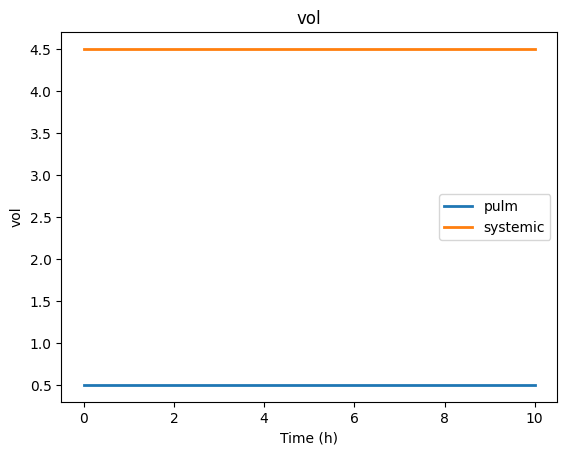

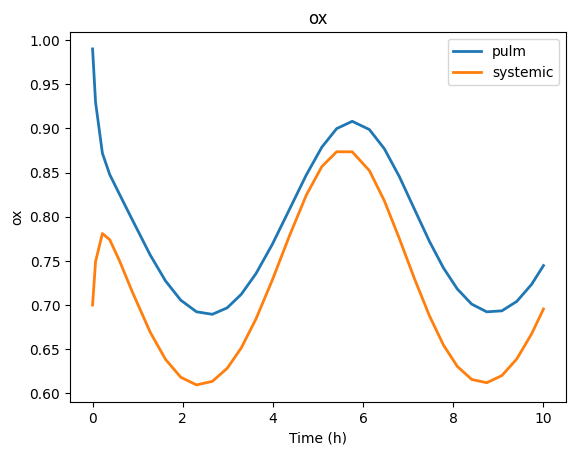

In [5]:
## Initial states and constants
speciesList = ['vol','ox','hgb']
compartmentList = ['pulm','systemic']

# Initialize state for each species
stateDict = vecToDict(0,speciesList,compartmentList)

# Homeostatic distribution of species (flows will be back-computed from this)
stateDict['vol']['systemic'] = 4.5
stateDict['vol']['pulm'] = 0.5

# Starting to build a special library of binding functions...
# First we need a function that defines 'is carried by'
carrierDict = {}
carrierDict['vol'] = []
carrierDict['hgb'] = 'vol'
carrierDict['ox'] = 'hgb'

stateDict['ox']['systemic'] = 0.7
stateDict['ox']['pulm'] = 0.99

stateDict['hgb']['systemic'] = 1.0
stateDict['hgb']['pulm'] = 1.0

# Build a vector of the homeostatic levels for numerical computations 
V = []
for cpt in compartmentList: 
    V.append(stateDict[speciesList[0]][cpt])
V = np.array(V)

# Initialize data structure over which we will compute rates
structDef_In = {}; structDef_Out = {}
structDef_Out['systemic']=['pulm']
structDef_Out['pulm']=['systemic']

flowK = graphToDict(0,compartmentList)
flowK = implementGraphStruct(flowK,compartmentList,structDef_Out,structDef_In)
print(flowK)
# Compute the rates from steay-state data (up to fluxes)
# NOTE: fluxes ARE important for perturbation response! 
# TODO: thread through functionalization k(t,x) everywhere
flowK = computeFlows(dictToGraph(flowK,compartmentList),V)
print(flowK)

flowK = graphToDict(flowK,compartmentList)


initialStateVec = dictToVec(stateDict,speciesList,compartmentList)

# Time span (h)
t_start = 0.0
t_end = 10.0
t_span = (t_start, t_end)

# initialized growth rates
growth = vecToDict(0,speciesList,compartmentList)

# initialize external inflows/outflows as functions
externalK = dictOfFxns(vecToDict(0,speciesList,compartmentList))
# systemic load
externalK['ox']['systemic'] = lambda t, x: x['hgb']['systemic']*(.40**2)-.4*(np.sin(t)+1.5)*x['ox']['systemic'] 
# Feedback relationship implemented in pulm 
externalK['ox']['pulm'] = lambda t, x: x['hgb']['pulm']*(.99**2)-.9*x['ox']['pulm'] 


### ODE solver call (Runge-Kutta)
solution = solve_ivp(odemasterfxn,[t_start,t_end],initialStateVec,method='RK45',args = (speciesList,compartmentList,flowK,externalK,growth,carrierDict))

### Plotting
tsPlot = vecToDict(solution.y,speciesList,compartmentList)
plotSpeciesList = ['vol','ox']
for species in plotSpeciesList:
    plt.figure()
    for key in tsPlot[species].keys():
        plt.plot(solution.t, tsPlot[species][key], linewidth=2,label=key)
    plt.ylabel(species)
    plt.xlabel('Time (h)')
    plt.title(species)
    plt.legend()